In [20]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os

Bragg peak data = line dose for a 69 MeV beam exported from RayPhysics.

In [21]:
path = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Line dose analysis\MeasuredBP_69MeV.xlsx"
data = pd.read_excel(path)

#Have depth start at zero
data['Depth'] = data['Depth'] - data['Depth'][0]
print(data)

     Depth   Dose
0      0.0  27.88
1      2.0  28.88
2      4.0  29.97
3      6.0  31.11
4      7.0  31.83
..     ...    ...
115   31.8   0.01
116   31.9   0.00
117   32.0   0.00
118   32.1   0.01
119   32.2   0.01

[120 rows x 2 columns]


(0.0, 100.01)

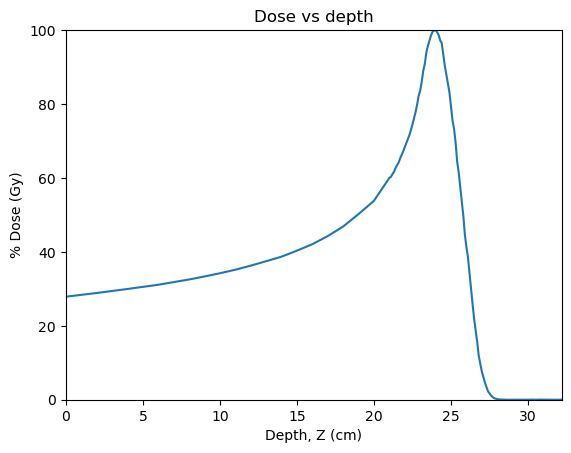

In [22]:
plt.plot(data['Depth'], data['Dose'],3)
plt.title('Dose vs depth')
plt.xlabel('Depth, Z (cm)')
plt.ylabel('% Dose (Gy)')
plt.xlim([min(data['Depth']), max(data['Depth'])])
plt.ylim([min(data['Dose']), max(data['Dose']+0.01)])

In [28]:
#Find indices of maximum dose
max_loc = np.where(data['Dose'] == max(data['Dose']))[0][-1] #The place to start calculations is the last of these
#Find index of zero
min_loc = np.where(data['Dose'] == min(data['Dose']))[0][0] #The place to finish is the first of these

#crop z and dose values 
z = np.array(data['Depth'][max_loc:min_loc+1])
dose = np.array(data['Dose'][max_loc:min_loc+1])

#Find all values that occur for doses
indices = np.unique(dose, return_index=True)[1]
dose_vals = [dose[ind] for ind in sorted(indices)]

der_vals = np.zeros([len(dose_vals),3])

for i in range(0, (len(dose_vals)-1), 1):
    #Take derivative at each point
    val_i = dose_vals[i]
    val_next = dose_vals[i+1]

    #Since many values repeat, take the derivative at the centre of each repeating section
    index = np.where(dose == val_i)[0]
    index = index[round(len(index)/2)]
    dose_i = dose[index]
    z_i = z[index]

    #Find next value
    index = np.where(dose == val_next)[0]
    index = index[round(len(index)/2)]
    dose_next = dose[index]
    z_next = z[index]


    derivative = (dose_next - dose_i)/(z_next - z_i)
    print('Derivative: ' + str(derivative) + ' Gy/mm')

    #Store data as [z, dose, derivative]
    der_vals[i,:] = z_i, dose_i, derivative


Derivative: -5.7999999999999 Gy/mm
Derivative: -7.399999999999844 Gy/mm
Derivative: -14.499999999999822 Gy/mm
Derivative: -7.400000000000512 Gy/mm
Derivative: -31.19999999999946 Gy/mm
Derivative: -30.099999999999625 Gy/mm
Derivative: -24.29999999999958 Gy/mm
Derivative: -24.00000000000057 Gy/mm
Derivative: -37.849999999999426 Gy/mm
Derivative: -23.199999999999743 Gy/mm
Derivative: -36.89999999999945 Gy/mm
Derivative: -51.30000000000287 Gy/mm
Derivative: -28.799999999999617 Gy/mm
Derivative: -39.89999999999945 Gy/mm
Derivative: -38.69999999999943 Gy/mm
Derivative: -51.20000000000296 Gy/mm
Derivative: -33.39999999999949 Gy/mm
Derivative: -27.699999999999637 Gy/mm
Derivative: -42.89999999999938 Gy/mm
Derivative: -41.85000000000088 Gy/mm
Derivative: -39.799999999999436 Gy/mm
Derivative: -31.599999999999554 Gy/mm
Derivative: -30.399999999999576 Gy/mm
Derivative: -38.29999999999946 Gy/mm
Derivative: -21.300000000000452 Gy/mm
Derivative: -14.79999999999979 Gy/mm
Derivative: -11.95000000000025

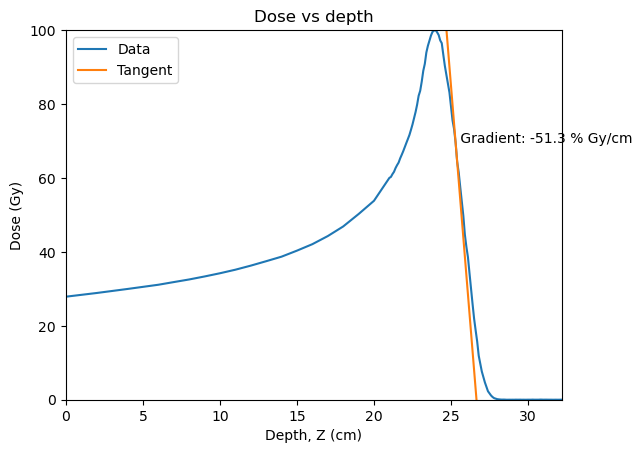

In [ ]:
#Display the steepest derivative
steepest_index = np.where(der_vals[:,2]==min(der_vals[:,2]))[0]
if len(steepest_index) > 1:
    steepest_index = steepest_index[round(len(steepest_index)/2)]
steepest = der_vals[steepest_index,:][0]

#Create tangent line
xes = np.arange((steepest[0]-2),(steepest[0]+2), 0.0001)
ys = steepest[2]*(xes-steepest[0]) + steepest[1]
text = ' Gradient: ' + str(round(steepest[2],4)) + ' % Gy/cm'

#plot data
plt.plot(data['Depth'], data['Dose'],label='Data')
plt.plot(xes, ys, label='Tangent')
plt.title('Dose vs depth')
plt.xlabel('Depth (mm)')
plt.ylabel('Dose (Gy)')
plt.xlim([min(data['Depth']), max(data['Depth'])])
plt.ylim([min(data['Dose']), max(data['Dose']+0.01)])
plt.text(steepest[0], steepest[1], text)
plt.legend()

Below is the data for the thickness of the ion chamber window and the film protective layer:

![](<../Line dose analysis/Markus chamber data.png>)
![alt text](<../Line dose analysis/Film data.png>)

In [57]:
#Calculate difference between films and ion chamber
ion_window = 30 #microns, from manual found online (https://www.ptwdosimetry.com/en/products/advanced-markus-electron-chamber)
print('Ion chamber window: ' + str(ion_window) + ' microns')
film_layer = 125 + 1*14 #microns, from manual provided by Tord
print('Distance to middle of active layer: ' + str(film_layer) + ' microns')

diff = abs(ion_window - film_layer)
print('Difference: ' + str(diff) + ' microns')

#Recalculate derivative from Gy/mm to Gy/micron
deriv_micron = steepest[2]/1000 #derivative in Gy/micron
print('Derivative: ' + str(deriv_micron) + ' Gy/micron')

#Calculate dose difference between ion chamber and film
dose_diff = abs(deriv_micron*diff)

#Calculate relative difference with dose at ion chamber at steepest point
dose_chamber = steepest[1]
fraction_diff = (dose_chamber-dose_diff)/dose_chamber
percent_diff = (dose_diff/dose_chamber)*100
print('Film dose = ' + str(round(fraction_diff,2)) + '*ion chamber dose')
print('Film dose is ' + str(round(percent_diff,2)) + '% lower than ion chamber dose')

Ion chamber window: 30 microns
Distance to middle of active layer: 139 microns
Difference: 109 microns
Derivative: -0.05130000000000287 Gy/micron
Film dose = 0.92*ion chamber dose
Film dose is 8.04% lower than ion chamber dose
